In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 4977
download_chandra_obsid 4977
chandra_repro 4977 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1690.7 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3765.1 kb/s
  vv       pdf        43 Kb  ####################          < 1 s  5676.2 kb/s
  cntr_img fits      417 Kb  ####################          < 1 s  26625.2 kb/s
  cntr_img jpg       660 Kb  ####################          < 1 s  39775.5 kb/s
  evt2     fits       66 Mb  ####################          < 1 s  79369.9 kb/s
  full_img fits      106 Kb  ####################          < 1 s  10227.1 kb/s
  full_img jpg        49 Kb  ####################          < 1 s  6277.7 kb/s
  bpix     fits       48 Kb  ####################          < 1 s  5885.9 kb/s
  fov      fits        6 Kb  ####################          < 1 s  1022.9 kb/s
  eph1     fits      282 Kb  ####################          

In [3]:
dmcopy "acisf04977_repro_evt2.fits[ccd_id=7]" c7.evt clob+
fluximage "c7.evt" abell2029 binsize=2 clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf189953929N005_asol1.fits found.
Bad-pixel file acisf04977_repro_bpix1.fits found.
Mask file acisf04977_000N005_msk1.fits found.

The output images will have 710 by 710 pixels, pixel size of 0.984 arcsec,
    and cover x=3522.5:4942.5:2,y=3112.5:4532.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 4977
Creating instrument map for obsid 4977
Creating exposure map for obsid 4977
Thresholding data for obsid 4977
Exposure-correcting image for obsid 4977

The following files were created:

 The clipped counts image is:
     abell2029_broad_thresh.img

 The clipped exposure map is:
     abell2029_broad_thresh.expmap

 The exposure-corrected image is:
     abell2029_broad_flux.img



In [4]:
dmcopy "acisf04977_repro_fov1.fits[ccd_id=7]" c7.fov clob+
dmcopy "abell2029_broad_thresh.img[sky=region(c7.fov)][opt full]" img_with_fov clob+


## Exclude point srcs


In [5]:
cat << EOM > ciao.reg
# Region file format: CIAO version 1.0
circle(3864.5183,3571.0756,20.410863)
circle(3989.5161,3347.0484,19.129071)
circle(4118.9925,3363.5201,23.330288)
circle(4244.2028,3565.3626,15.837317)
circle(4551.4603,3439.9762,17.17467)
circle(4060.042,3487.4618,23.425518)
circle(4195.866,4228.868,14.400337)
circle(4231.571,4023.179,8.1002516)
circle(4594.5131,4034.4216,18.159209)
circle(4612.705,4124.623,20.036573)
circle(4056.321,4249.4199,16.258138)
circle(4140.3128,3758.8112,8.9226531)
circle(4221.6053,3729.3411,9.6319044)
circle(4270.4822,3739.5,11.518549)
circle(4592.764,3782.988,26.945645)
circle(4162.764,3472.988,18.490854)
circle(4349.5,4271.5,6.4448495)
EOM

## Adaptive smooth

In [6]:
pset dmimgadapt infile="img_with_fov[exclude sky=region(ciao.reg)]"
pset dmimgadapt outfile=smoothed_image
pset dmimgadapt function=tophat
pset dmimgadapt counts=250
pset dmimgadapt minrad=1 maxrad=50 numrad=99 radscale=linear
pset dmimgadapt radfile=radii_min_250_counts
dmimgadapt mode=h clobber=yes verbose=0


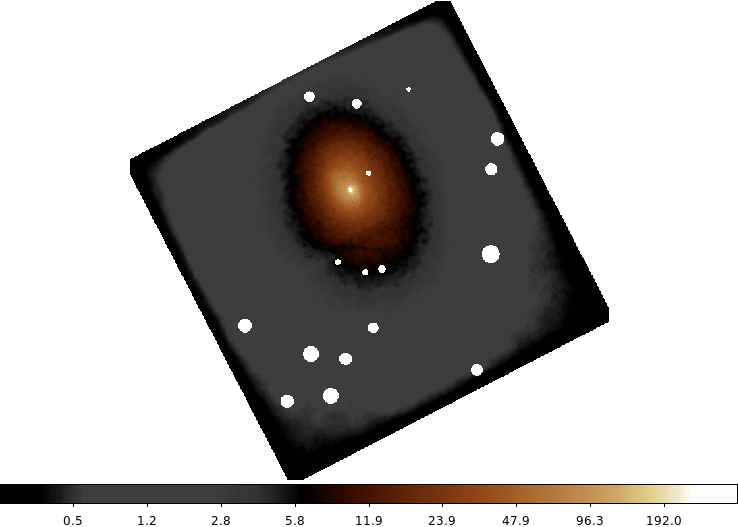

In [7]:
ds9 smoothed_image -scale log \
  -zoom to fit \
  -cmap load $ASCDS_INSTALL/contrib/data/heart.lut \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

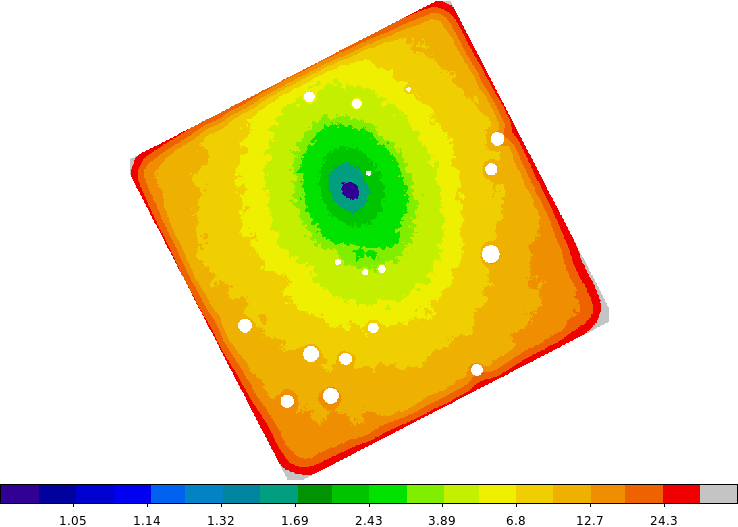

In [8]:
ds9 radii_min_250_counts -scale log \
  -zoom to fit \
  -cmap load $ASCDS_INSTALL/contrib/data/20_colors.lut \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

## Using 

In [9]:
punlearn dmcoords
dmcoords radii_min_250_counts asol= op=cel ra=15:11:00.049 dec=+5:42:26.00 celfmt=hms verb=0 
pget dmcoords x y


4057.50599965482
3699.505054973268


In [10]:
evalpos radii_min_250_counts 15:11:00.049 +5:42:26.00

radii_min_250_counts	15:11:00.049 +5:42:26.00	5.5 []


In [11]:
dmstat abell2029_broad_thresh.img"[sky=circle(4057.50599965482,3699.505054973268,11)]" cen- sig- med-

EVENTS_IMAGE
    min:	0 	      @:	( 4055.5 3693.5 )
    max:	8 	      @:	( 4051.5 3691.5 )
   mean:	2.9072164948 
    sum:	282 
   good:	97 
   null:	47 


In [12]:
cat << EOM > p1.py
from pycrates import read_file
from ciao_contrib.runtool import dmstat
import numpy as np

img = read_file("radii_min_250_counts")

binsize=2.0

img_data = img.get_image().values
xlen = len(img_data[0])
ylen = len(img_data)

sky = img.get_transform("sky")

outfile = open("sample.out","w")

for jj in range(ylen):
   for ii in range(xlen):
       # Skip edges
       if np.isnan(img_data[jj,ii]) or img_data[jj,ii]>=1.1:
           continue
       xy = sky.apply( [[ii+1.0,jj+1.0]] )
       region = "circle({},{},{})".format( xy[0][0], xy[0][1], binsize*img_data[jj,ii])
       dmstat( "abell2029_broad_thresh.img[sky={}]".format(region), 
                     centroid=False, sigma=False, median=False )
       outfile.write("{}\t{}\t{}\n".format(xy[0][0], xy[0][1], dmstat.out_sum))

outfile.close()
EOM

python p1.py

In [13]:
head -10 sample.out

4189.5	3943.5	406
4191.5	3943.5	402
4177.5	3945.5	401
4181.5	3945.5	445
4183.5	3945.5	397
4185.5	3945.5	453
4187.5	3945.5	384
4193.5	3945.5	397
4175.5	3947.5	430
4177.5	3947.5	426
